In [173]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from calculator import SeaIceCalc, Habitability, SST

In [174]:
ice_tot = []
ice_nhem = []
ice_shem = []

st_tot = []
st_nhem = []
st_shem = []

sm_tot = []
sm_nhem = []
sm_shem = []

tsurf_tot = []
tsurf_nhem = []
tsurf_shem = []

months = []

In [175]:
# For every month in the dataset:
    # Run ice calc and habitability calc
    # Append value to the respective array

ds = xr.open_dataset("../axial_tilt/output1.nc")
ds_crop = ds.sel(time=slice("2001-1-1","2002-1-1"))
monthly_data = (ds_crop.groupby("time.month"))

 
# monthly_data is a container that holds pairs (month_label, subset_of_dataset)
# The month would be monthly_data[0] - name this month
# The data for a given month would be monthly_data[1] - name this data
# When you loop over things like this, the structure is: for key, value in my_dict():


for month, data in monthly_data:

    # Append values to the months array
    months.append(month)


    # Calculation over whole globe
    ice_frac = SeaIceCalc.ice_frac(data)[0]
    fraction_sm = Habitability.fraction(data, "sm")[0]
    fraction_st = Habitability.fraction(data, "st")[0]
    fraction_tsurf = Habitability.fraction(data, "tsurf")[0]

    ice_tot.append(ice_frac)
    sm_tot.append(fraction_sm)
    st_tot.append(fraction_st)
    tsurf_tot.append(fraction_tsurf)

    # Calculation over northern hemisphere
    ice_n = SeaIceCalc.ice_frac(data, lat=slice(0,24))[0]
    sm_n = Habitability.fraction(data, "sm", lat=slice(0,24))[0]
    st_n = Habitability.fraction(data, "st", lat=slice(0,24))[0]
    tsurf_n = Habitability.fraction(data, "tsurf", lat=slice(0,24))[0]

    ice_nhem.append(ice_n)
    sm_nhem.append(sm_n)
    st_nhem.append(st_n)
    tsurf_nhem.append(tsurf_n)

    # Calculation over southern hemisphere
    ice_s = SeaIceCalc.ice_frac(data, lat=slice(24,48))[0]
    sm_s = Habitability.fraction(data, "sm", lat=slice(24,48))[0]
    st_s = Habitability.fraction(data, "st", lat=slice(24,48))[0]
    tsurf_s = Habitability.fraction(data, "tsurf", lat=slice(24,48))[0]

    ice_shem.append(ice_s)
    sm_shem.append(sm_s)
    st_shem.append(st_s)
    tsurf_shem.append(tsurf_s)


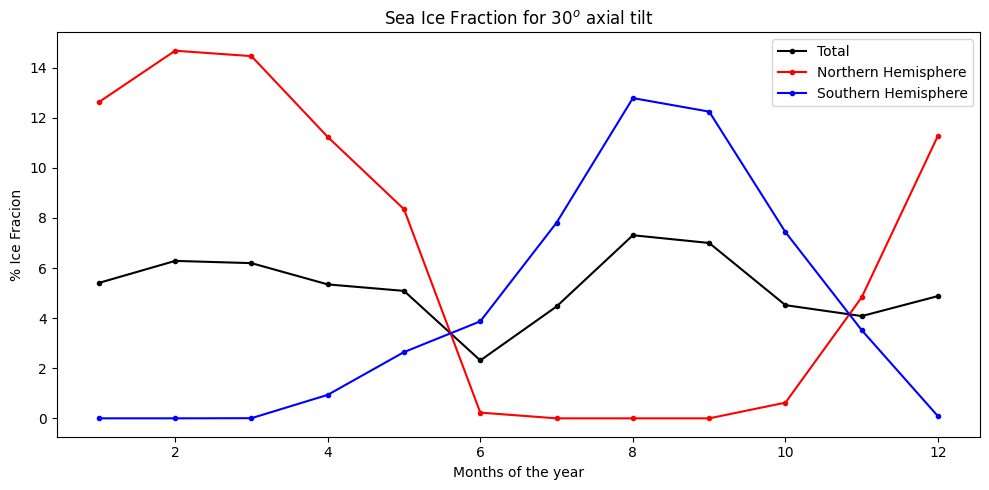

In [176]:
fig = plt.figure(figsize=(10, 5))
plt.plot(months, ice_tot, marker='.', color='black', label="Total")
plt.plot(months, ice_nhem, marker='.', color='red', label="Northern Hemisphere")
plt.plot(months, ice_shem, marker='.', color ='blue', label="Southern Hemisphere")

plt.xlabel('Months of the year')
plt.ylabel('% Ice Fracion')
plt.title("Sea Ice Fraction for 30$^o$ axial tilt")
plt.legend()
plt.tight_layout()
plt.show()

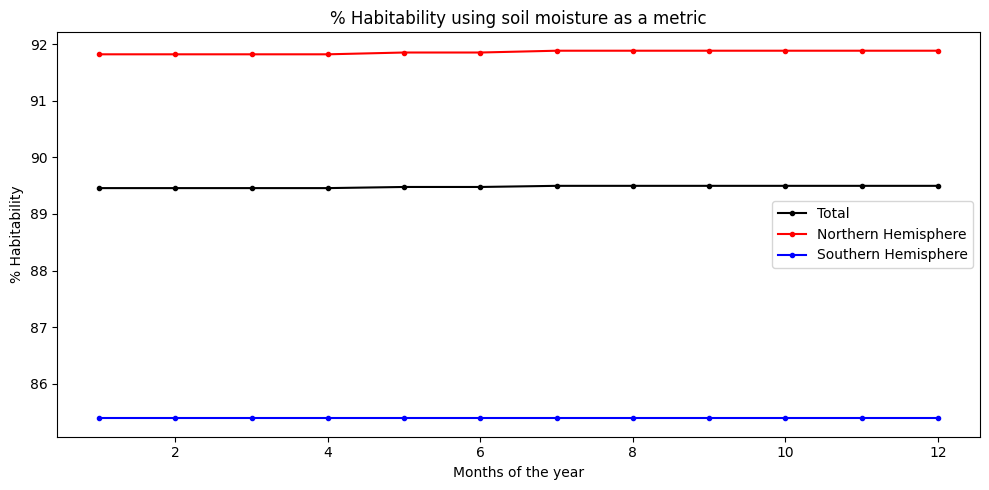

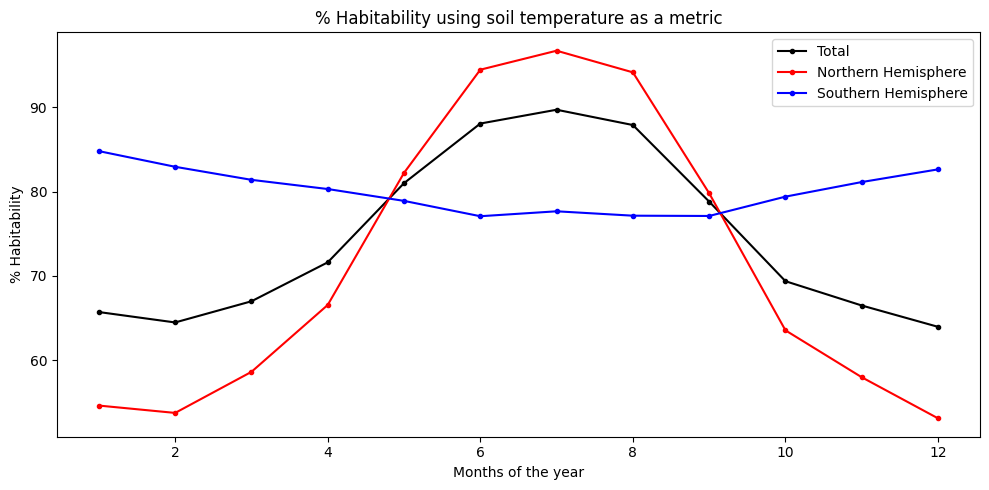

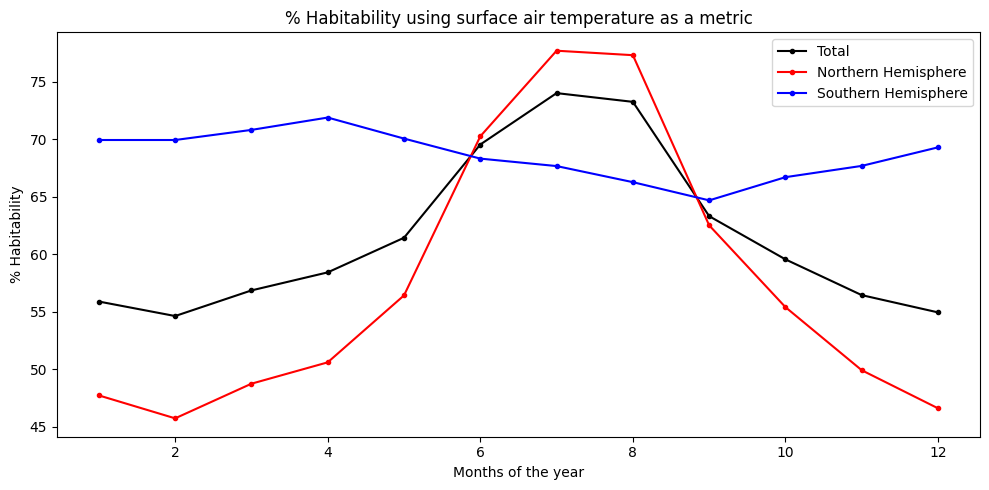

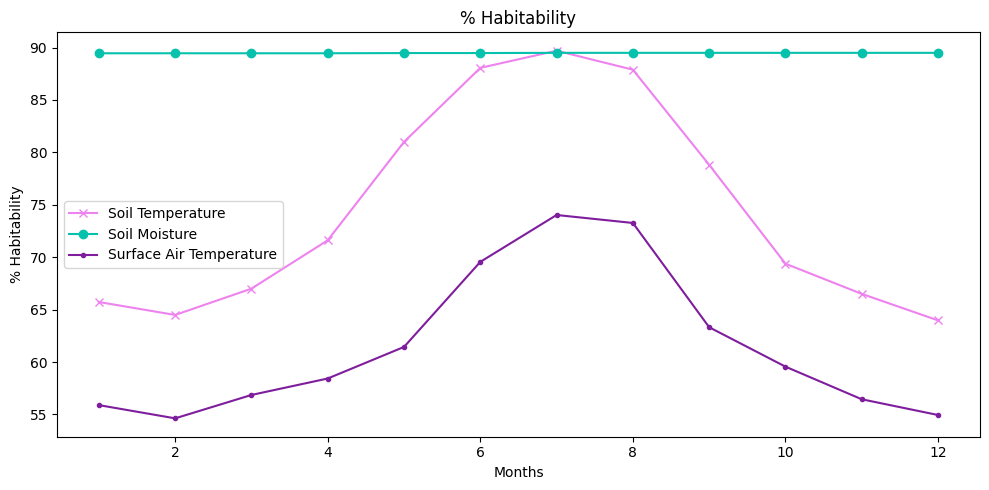

In [177]:
fig = plt.figure(figsize=(10, 5))
plt.plot(months, sm_tot, marker='.', color='black', label="Total")
plt.plot(months, sm_nhem, marker='.', color='red', label="Northern Hemisphere")
plt.plot(months, sm_shem, marker='.', color ='blue', label="Southern Hemisphere")

plt.xlabel('Months of the year')
plt.ylabel('% Habitability')
plt.title("% Habitability using soil moisture as a metric")
plt.legend()
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(months, st_tot, marker='.', color='black', label="Total")
plt.plot(months, st_nhem, marker='.', color='red', label="Northern Hemisphere")
plt.plot(months, st_shem, marker='.', color ='blue', label="Southern Hemisphere")

plt.xlabel('Months of the year')
plt.ylabel('% Habitability')
plt.title("% Habitability using soil temperature as a metric")
plt.legend()
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(months, tsurf_tot, marker='.', color='black', label="Total")
plt.plot(months, tsurf_nhem, marker='.', color='red', label="Northern Hemisphere")
plt.plot(months, tsurf_shem, marker='.', color ='blue', label="Southern Hemisphere")

plt.xlabel('Months of the year')
plt.ylabel('% Habitability')
plt.title("% Habitability using surface air temperature as a metric")
plt.legend()
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(months, st_tot, marker='x', color='#EE82EE', label="Soil Temperature")
plt.plot(months, sm_tot, marker='o', color='#06C2AC', label="Soil Moisture")
plt.plot(months, tsurf_tot, marker='.', color ='#7E1E9C', label="Surface Air Temperature")
plt.xlabel('Months')
plt.ylabel('% Habitability')
plt.title("% Habitability")
plt.legend()
plt.tight_layout()
plt.show()

In [178]:
sst = []
sst_s = []
sst_n = []


for month, data in monthly_data:

    # Calculate mean sea surface temperature
    tot = SST.temp(data)
    n = SST.temp(data, lat=slice(0,24))
    s = SST.temp(data, lat=slice(24,48))

    sst.append(tot)
    sst_n.append(n)
    sst_s.append(s)


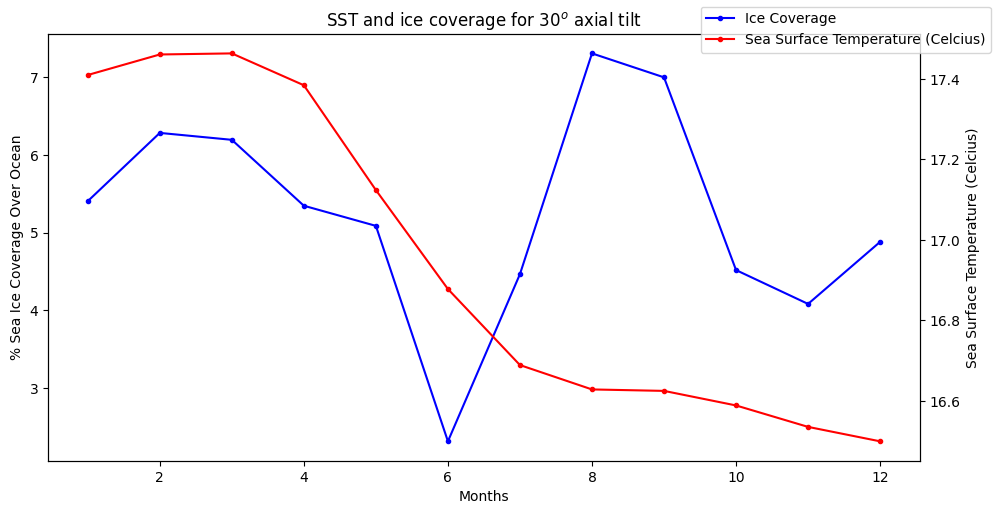

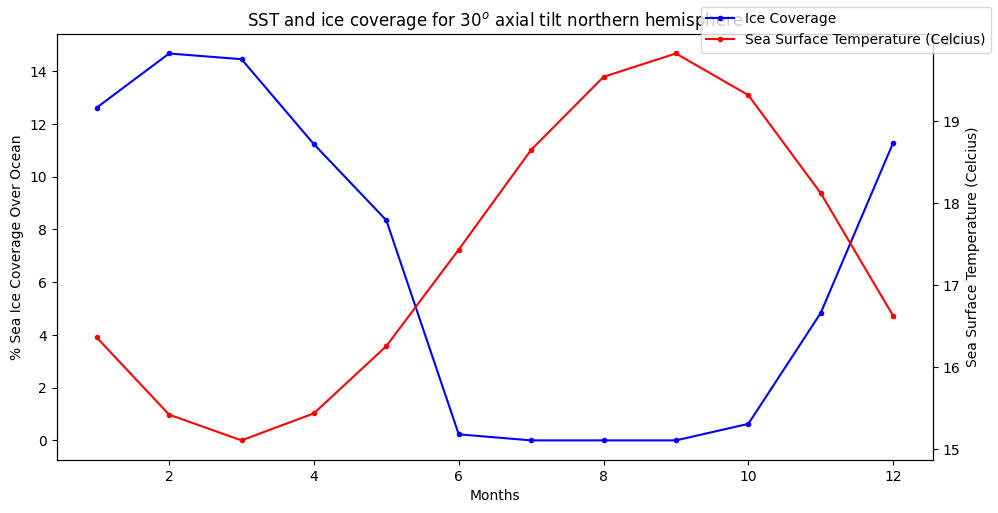

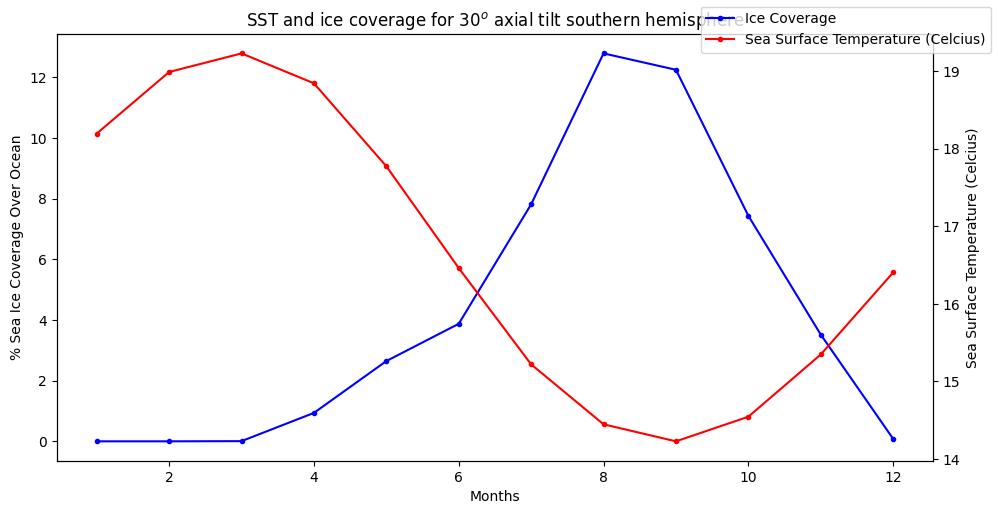

In [179]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# First y-axis
ax1.plot(months, ice_tot, marker='.', color='blue', label="Ice Coverage")
ax1.set_xlabel("Months")
ax1.set_ylabel("% Sea Ice Coverage Over Ocean")

# Second y-axis (shares the same x-axis)
ax2 = ax1.twinx()
ax2.plot(months, sst, marker='.', color='red', label="Sea Surface Temperature (Celcius)")
ax2.set_ylabel("Sea Surface Temperature (Celcius)")

fig.legend(loc="upper right")
plt.tight_layout()
plt.title("SST and ice coverage for 30$^o$ axial tilt")
plt.show()

fig, ax1 = plt.subplots(figsize=(10, 5))

# First y-axis
ax1.plot(months, ice_nhem, marker='.', color='blue', label="Ice Coverage")
ax1.set_xlabel("Months")
ax1.set_ylabel("% Sea Ice Coverage Over Ocean")

# Second y-axis (shares the same x-axis)
ax2 = ax1.twinx()
ax2.plot(months, sst_n, marker='.', color='red', label="Sea Surface Temperature (Celcius)")
ax2.set_ylabel("Sea Surface Temperature (Celcius)")

fig.legend(loc="upper right")
plt.tight_layout()
plt.title("SST and ice coverage for 30$^o$ axial tilt northern hemisphere")
plt.show()

fig, ax1 = plt.subplots(figsize=(10, 5))

# First y-axis
ax1.plot(months, ice_shem, marker='.', color='blue', label="Ice Coverage")
ax1.set_xlabel("Months")
ax1.set_ylabel("% Sea Ice Coverage Over Ocean")

# Second y-axis (shares the same x-axis)
ax2 = ax1.twinx()
ax2.plot(months, sst_s, marker='.', color='red', label="Sea Surface Temperature (Celcius)")
ax2.set_ylabel("Sea Surface Temperature (Celcius)")

fig.legend(loc="upper right")
plt.tight_layout()
plt.title("SST and ice coverage for 30$^o$ axial tilt southern hemisphere")
plt.show()

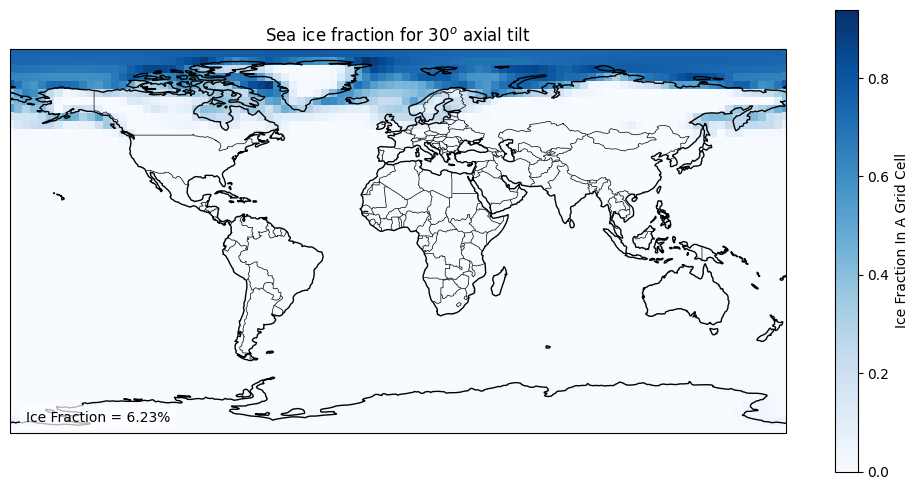

In [182]:
ds_crop = ds.sel(time=slice("2001-02-01", "2001-03-31"))

ice_concentration = SeaIceCalc.ice_frac(ds_crop)[1]
ice_fraction = SeaIceCalc.ice_frac(ds_crop)[0]


# Creating figures
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

ice_concentration.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Ice Fraction In A Grid Cell"},
    cmap="Blues"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

ax.text(0.02, 0.02, f"Ice Fraction = {ice_fraction:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.title("Sea ice fraction for 30$^o$ axial tilt")
plt.tight_layout()

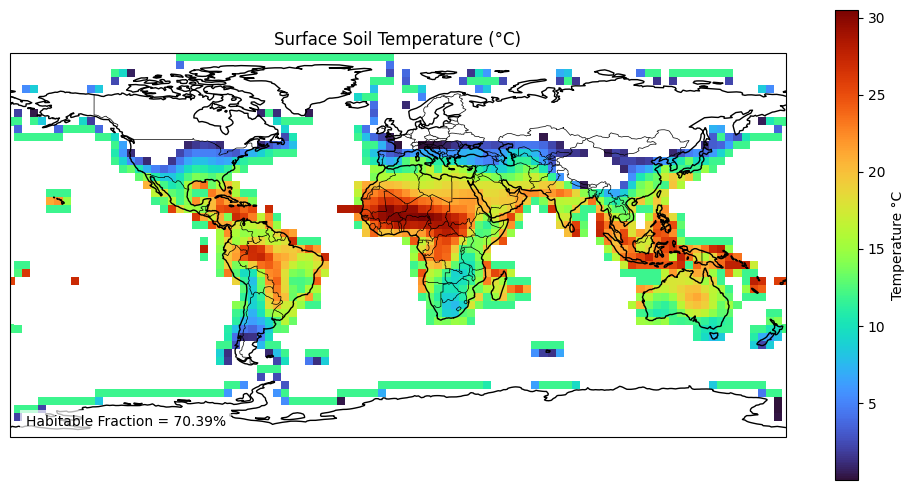

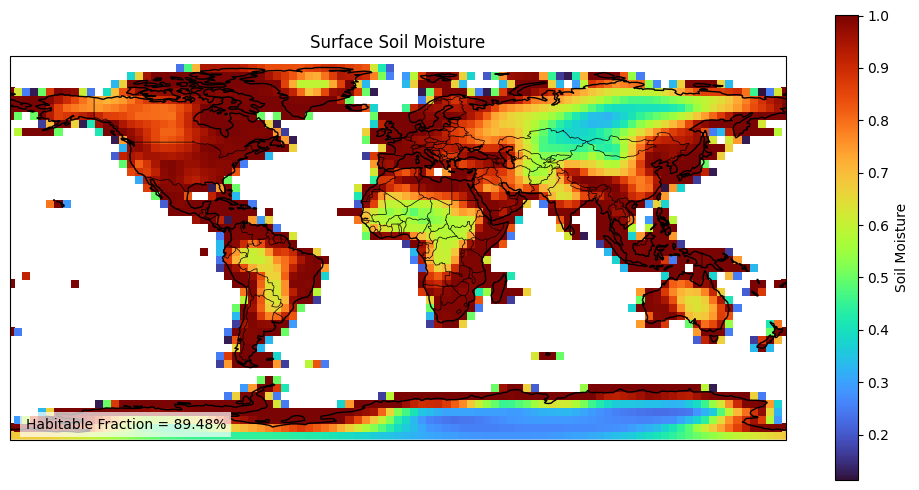

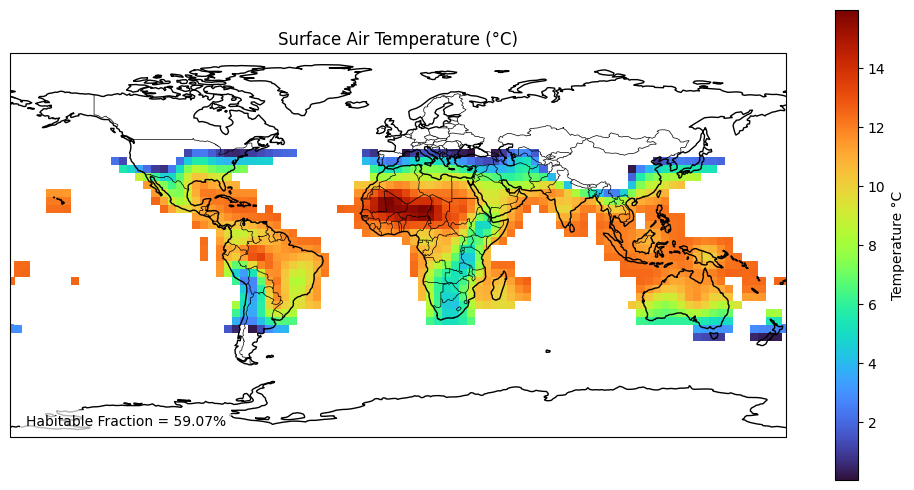

In [181]:
ds_crop = ds.sel(time=slice("2001-01-01", "2001-12-31"))

fraction_sm = Habitability.fraction(ds_crop, "sm")[0]
fraction_st = Habitability.fraction(ds_crop, "st")[0]
fraction_tsurf = Habitability.fraction(ds_crop, "tsurf")[0]

sm = Habitability.fraction(ds_crop, "sm")[1]
st = Habitability.fraction(ds_crop, "st")[1]
tsurf = Habitability.fraction(ds_crop, "tsurf")[1]

sm_hab = Habitability.fraction(ds_crop, "sm")[2]
st_hab = Habitability.fraction(ds_crop, "st")[2]
tsurf_hab = Habitability.fraction(ds_crop, "tsurf")[2]

# Creating figures
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

st.where(st_hab).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature °C"},
    cmap="turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Soil Temperature (°C)")

ax.text(0.02, 0.02, f"Habitable Fraction = {fraction_st:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

sm.where(sm_hab).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Soil Moisture"},
    cmap="turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Soil Moisture")

ax.text(0.02, 0.02, f"Habitable Fraction = {fraction_sm:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

tsurf.where(tsurf_hab).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature °C"},
    cmap="turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Air Temperature (°C)")

ax.text(0.02, 0.02, f"Habitable Fraction = {fraction_tsurf:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()
